# EfficientAD: Detección de Anomalías
[Link al paper](https://drive.google.com/file/d/1cW98xiA8VVH1O5hCrrqukxJL9F0W7sCW/view?usp=drive_link)

## Introducción

La **Detección de Anomalías (Anomaly Detection, AD)** es una rama de la visión por computadora cuyo objetivo es identificar regiones o imágenes que difieren del comportamiento normal observado durante el entrenamiento.

A diferencia de un problema de clasificación tradicional, en AD generalmente se dispone únicamente de ejemplos **normales (sin defectos)** para entrenar el modelo. Posteriormente, durante la inferencia, el sistema debe detectar cualquier desviación respecto de ese comportamiento aprendido.

Este enfoque resulta especialmente útil en inspección industrial, donde los defectos son escasos, difíciles de catalogar o presentan gran variabilidad.

---

## Arquitectura EfficientAD

EfficientAD combina tres redes neuronales:

1. **Teacher (PDN)**
2. **Student (PDN)**
3. **Autoencoder**

Durante el entrenamiento, la red *teacher* permanece congelada y actúa como generadora de representaciones visuales de referencia. La red *student* aprende a reproducir dichas representaciones utilizando únicamente imágenes normales. Paralelamente, un autoencoder aprende a reconstruir las características presentes en las muestras de entrenamiento.

Durante la inferencia, las discrepancias entre las salidas de estas redes permiten detectar regiones anómalas.

De forma simplificada:

```text
Imagen
   │
   ├──► Teacher (congelada)
   │         │
   │         ▼
   │   Características de referencia
   │
   ├──► Student
   │         │
   │         ▼
   │   Características estimadas
   │
   └──► Autoencoder
             │
             ▼
      Reconstrucción de características
```

Las diferencias entre estas representaciones constituyen la base para la detección de anomalías.

---

## ¿Qué es una PDN?

Las redes utilizadas como *teacher* y *student* son denominadas **PDN (Patch Description Network)**.

A diferencia de una CNN clásica diseñada para clasificación, cuyo objetivo final es asignar una etiqueta a toda la imagen, una PDN está orientada a producir una descripción compacta de los patrones visuales presentes en pequeñas regiones (*patches*) de la imagen.

Su salida no representa clases, sino un conjunto de características espaciales que describen texturas, bordes, formas y estructuras locales.

Esto permite comparar, píxel a píxel o región a región, qué tan similar es una imagen respecto de las observadas durante el entrenamiento.

---

## ¿Qué es un Autoencoder?

Un **autoencoder** es una red neuronal entrenada para reconstruir su propia entrada.

Consta de dos partes principales:

* **Encoder:** comprime la información en una representación interna.
* **Decoder:** reconstruye la información a partir de dicha representación.

```text
Entrada
   │
   ▼
Encoder
   │
Representación Latente
   │
   ▼
Decoder
   │
   ▼
Reconstrucción
```

Cuando el autoencoder se entrena únicamente con imágenes normales, aprende a reconstruir correctamente las estructuras habituales del conjunto de entrenamiento.

Si durante la inferencia aparece una anomalía, dicha región suele reconstruirse con mayor error, generando una señal útil para detectar defectos.

---

## Generación de mapas de anomalía

EfficientAD combina dos fuentes de información:

### Mapa Student–Teacher

Mide la diferencia entre las características producidas por la red teacher y las estimadas por la student.

Una diferencia elevada indica que la student no pudo reproducir adecuadamente el comportamiento esperado para esa región de la imagen.

### Mapa Autoencoder–Student

Mide la discrepancia entre la reconstrucción realizada por el autoencoder y la representación producida por la student.

Las anomalías suelen generar errores significativos en esta comparación.

---

## Anomalías locales y globales

La combinación de ambos mapas permite detectar:

* **Anomalías locales:** defectos pequeños, grietas, manchas o contaminaciones puntuales.
* **Anomalías globales:** cambios más extensos en la apariencia general del objeto.

Finalmente, ambos mapas se fusionan para obtener un **mapa de anomalías** donde cada píxel recibe un puntaje asociado a su grado de anormalidad.

A partir de este mapa es posible:

* Visualizar las regiones defectuosas.
* Generar máscaras binarias mediante umbralización.
* Calcular un puntaje global de anomalía para clasificar la imagen completa como normal o defectuosa.

De esta forma, EfficientAD proporciona simultáneamente una decisión a nivel imagen y una localización espacial de las anomalías detectadas.


# 1. Setup

El código está organizado para poder ser desplegado en un entorno de Colab o correr en forma local.
Considerar que una T4 alcanza un speedup x100 en tiempos de inferencias comparado con una computadora de gama media sin GPU, por lo que es mandatorio el uso de este entorno para entrenamiento.

Se proveen una celda que despliega tanto en local como en Colab:

- Dataset
- Modelos previamente entrenados
- Tests previamente corridos

Al finalizar el entrenamiento se realiza el empaquetado del modelo final y de los tests, para dar persistencia entre sesiones (muy útil cuando se trabaja en un entorno efímero como Colab).

La instalación del software para gestionar EAD se realiza automáticamente.

In [ ]:
# ============================================================
# 1. SISTEMA Y MANEJO DE ARCHIVOS
# ============================================================
import os
import sys
import time
import shutil
import zipfile
from pathlib import Path

# ============================================================
# 2. MANIPULACIÓN DE DATOS
# ============================================================
import random
import itertools
import numpy as np
import pandas as pd

# ============================================================
# 3. VISUALIZACIÓN
# ============================================================
from matplotlib import pyplot as plt
from PIL import Image

# ============================================================
# 4. DEEP LEARNING (PYTORCH)
# ============================================================
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

# ============================================================
# 5. EVALUACIÓN DE MODELOS
# ============================================================
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 6. UTILIDADES
# ============================================================
from tqdm import tqdm

In [ ]:
# =========================
# CONFIG
# =========================
dataset = "mvtec_ad"
subdataset = "bottle"
dataset_name = "mvtec_anomaly_detection"  # path comprimido
#dataset = "pc"
#subdataset = "carpetas"
#dataset_name = "pc"

zip_dataset = f"dataset_{dataset}_{subdataset}.zip"
zip_model = f"model_{dataset}_{subdataset}.zip"
zip_src = "EfficientAD.zip"

try:
    from google.colab import drive

    EN_COLAB = True
    BASE = Path("/content")
    drive.mount('/content/drive')

    drive_dir = Path("/content/drive/MyDrive/Colab Notebooks/VISION/02_efficientAD")

    for archivo in [zip_dataset, zip_model, zip_src]:

        src = drive_dir / archivo
        dst = BASE / archivo

        if src.exists() and not dst.exists():
            print(f"Copiando {archivo}")
            shutil.copy(src, dst)
except:
    EN_COLAB = False
    BASE = Path(".").resolve()


# =========================
# DIRECTORIOS BASE
# =========================
datasets_dir = BASE / "datasets"
models_dir = BASE / "models"
test_dir = BASE / "test"
src_dir = BASE / "src"
ead_dir = src_dir / "EfficientAD"
train_output_dir = models_dir / dataset / subdataset
test_output_dir = test_dir / dataset / subdataset

datasets_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)
test_dir.mkdir(exist_ok=True)
src_dir.mkdir(exist_ok=True)
train_output_dir.mkdir(parents=True, exist_ok=True)
test_output_dir.mkdir(parents=True, exist_ok=True)

dataset_root = datasets_dir / dataset_name / subdataset

# =========================
# 1. DATASET
# =========================
dataset_zip_path = BASE / zip_dataset

if not dataset_root.exists():
    print("Extrayendo dataset...")

    if not dataset_zip_path.exists():
        raise FileNotFoundError(f"No existe {dataset_zip_path}")

    with zipfile.ZipFile(dataset_zip_path, "r") as z:
        z.extractall(datasets_dir)
else:
    print("Dataset ya disponible")

# =========================
# 2. MODELO (solo deja zip, opcional extracción)
# =========================
model_zip_path = BASE / zip_model

if model_zip_path.exists():
    print("Modelo zip disponible:", zip_model)
    with zipfile.ZipFile(model_zip_path, "r") as z:
        z.extractall(BASE)
else:
    print("No se encontró modelo zip: ", zip_model)

# =========================
# 3. EFFICIENTAD SRC
# =========================
src_zip_path = BASE / zip_src

if not ead_dir.exists():
    print("Extrayendo EfficientAD...")

    if not src_zip_path.exists():
        raise FileNotFoundError(f"No existe {src_zip_path}")

    with zipfile.ZipFile(src_zip_path, "r") as z:
        z.extractall(src_dir)

# agregar al path
sys.path.append(str(ead_dir))
import efficientad as ead

print("EfficientAD listo desde:", ead_dir)

# =========================
# OUTPUT FINAL
# =========================
print("\n--- RESUMEN ---")
print("Dataset:", dataset_root)
print("Models :", models_dir)
print("EAD    :", ead_dir)

print(f'Directorio de entrenamiento:  {train_output_dir}')
print(f'Directorio de test: {test_output_dir}')
print(f'Modelo a utilizar:  {zip_model}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando dataset_mvtec_ad_bottle.zip
Copiando model_mvtec_ad_bottle.zip
Extrayendo dataset...
Modelo zip disponible: model_mvtec_ad_bottle.zip
EfficientAD listo desde: /content/src/EfficientAD

--- RESUMEN ---
Dataset: /content/datasets/mvtec_anomaly_detection/bottle
Models : /content/models
EAD    : /content/src/EfficientAD
Directorio de entrenamiento:  /content/models/mvtec_ad/bottle
Directorio de test: /content/test/mvtec_ad/bottle
Modelo a utilizar:  model_mvtec_ad_bottle.zip


# 2. Entrenamiento

## 2.1. Configuración general

In [18]:
# Defino el destino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device = {device}")

# Para repetibilidad
seed = 42

# Definición de hiperparámetros
out_channels = 384
image_size = 256
train_steps = 30000
pretrain_penalty = False

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Device = cuda


## 2.2. Dataset + loaders

Crea los datasets de entrenamiento y prueba, y divide el conjunto de entrenamiento en subconjuntos de entrenamiento y validación.

In [19]:
full_train_set = ead.ImageFolderWithoutTarget(
    os.path.join(dataset_root, "train"),
    transform=transforms.Lambda(ead.train_transform)
)

test_set = ead.ImageFolderWithPath(
    os.path.join(dataset_root, "test")
)

train_size = int(0.9 * len(full_train_set))
val_size = len(full_train_set) - train_size

rng = torch.Generator().manual_seed(seed)

train_set, validation_set = torch.utils.data.random_split(
    full_train_set,
    [train_size, val_size],
    generator=rng
)

train_loader = DataLoader(
    train_set,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

validation_loader = DataLoader(validation_set, batch_size=1)

train_loader_infinite = ead.InfiniteDataloader(train_loader)
penalty_loader_infinite = itertools.repeat(None)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 2.3. Modelos + optimizador

In [21]:
# Crear modelos
# El teacher toma los pesos obtenidos en el proyecto EAD (son los que no se entrenan)
weights_filename = ead_dir / 'models' / 'teacher_small.pth'

teacher = ead.get_pdn_small(out_channels)
student = ead.get_pdn_small(2 * out_channels)
autoencoder = ead.get_autoencoder(out_channels)

state_dict = torch.load(weights_filename, map_location="cpu")
teacher.load_state_dict(state_dict)

# Se congela a teacher y se deja como entrenables al student y al autoencoder
teacher.eval()
student.train()
autoencoder.train()

teacher.to(device)
student.to(device)
autoencoder.to(device)

# Calcula media y desvío de las salidas del teacher sobre el conjunto normal.
# Estos estadísticos se utilizan para normalizar los mapas de características.
teacher_mean, teacher_std = ead.teacher_normalization(
    teacher,
    train_loader
)

# Configuración del optimizador que ajusta simultáneamente los pesos del student y del autoencoder.
optimizer = torch.optim.Adam(
    itertools.chain(student.parameters(), autoencoder.parameters()),
    lr=1e-4,
    weight_decay=1e-5
)

# Reduce la tasa de aprendizaje al 10% de su valor inicial
# cuando se alcanza el 95% de las iteraciones de entrenamiento.
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=int(0.95 * train_steps),
    gamma=0.1
)


Computing std of features: 100%|██████████| 188/188 [00:08<00:00, 23.06it/s]


## 2.4. Loop de entrenamiento

El teacher permanece congelado mientras student y autoencoder aprenden a reproducir las representaciones observadas en imágenes normales.

In [ ]:

tqdm_obj = tqdm(range(train_steps))
for iteration, (image_st, image_ae), image_penalty in zip(
        tqdm_obj, train_loader_infinite, penalty_loader_infinite):

    image_st = image_st.to(device)
    image_ae = image_ae.to(device)
    if image_penalty is not None:
      image_penalty = image_penalty.to(device)

    # Salida de referencia generada por el teacher normalizado.
    # El student intentará aproximar estas características.
    with torch.no_grad():
        teacher_output_st = teacher(image_st)
        teacher_output_st = (teacher_output_st - teacher_mean) / teacher_std

    # Error Student-Teacher.
    # Solo se consideran las discrepancias más grandes (hard samples),
    # forzando al student a aprender las regiones más difíciles
    student_output_st = student(image_st)[:, :out_channels]
    distance_st = (teacher_output_st - student_output_st) ** 2
    d_hard = torch.quantile(distance_st, q=0.999)
    loss_hard = torch.mean(distance_st[distance_st >= d_hard])

    # Penalización opcional para evitar activaciones espurias
    # del student sobre imágenes externas al conjunto normal.
    if image_penalty is not None:
        student_output_penalty = student(image_penalty)[:, :out_channels]
        loss_penalty = torch.mean(student_output_penalty**2)
        loss_st = loss_hard + loss_penalty
    else:
        loss_st = loss_hard

    # El autoencoder aprende a reconstruir las características
    # producidas por el teacher sobre imágenes normales.
    ae_output = autoencoder(image_ae)
    with torch.no_grad():
        teacher_output_ae = teacher(image_ae)
        teacher_output_ae = (teacher_output_ae - teacher_mean) / teacher_std
    student_output_ae = student(image_ae)[:, out_channels:]
    # Error de reconstrucción del autoencoder respecto del teacher.
    distance_ae = (teacher_output_ae - ae_output)**2
    # El segundo bloque de salida del student intenta aproximar
    # la reconstrucción producida por el autoencoder.
    distance_stae = (ae_output - student_output_ae)**2
    loss_ae = torch.mean(distance_ae)
    loss_stae = torch.mean(distance_stae)
    # Función de costo total propuesta por EfficientAD.
    # Combina la alineación Student-Teacher y Autoencoder-Student.
    loss_total = loss_st + loss_ae + loss_stae

    # Actualización de parámetros del student y del autoencoder.
    optimizer.zero_grad()
    loss_total.backward()
    optimizer.step()
    scheduler.step()

    if iteration % 10 == 0:
        tqdm_obj.set_description(
            "Current loss: {:.4f}  ".format(loss_total.item()))

    # Se almacenan checkpoints periódicos para evitar perder
    # el entrenamiento ante una interrupción.
    if iteration % 1000 == 0:
        torch.save(teacher.state_dict(), os.path.join(train_output_dir,'teacher_tmp.pth'))
        torch.save(student.state_dict(), os.path.join(train_output_dir,'student_tmp.pth'))
        torch.save(autoencoder.state_dict(), os.path.join(train_output_dir,'autoencoder_tmp.pth'))

    # Se corre una evaluación intermedia
    if iteration % 10000 == 0 and iteration > 0:
        teacher.eval()
        student.eval()
        autoencoder.eval()

        q_st_start, q_st_end, q_ae_start, q_ae_end = ead.map_normalization(
            validation_loader=validation_loader,
            teacher=teacher,
            student=student,
            autoencoder=autoencoder,
            teacher_mean=teacher_mean,
            teacher_std=teacher_std,
            desc='Intermediate map normalization'
            )
        auc = ead.test(
            test_set=test_set,
            teacher=teacher,
            student=student,
            autoencoder=autoencoder,
            teacher_mean=teacher_mean,
            teacher_std=teacher_std,
            q_st_start=q_st_start,
            q_st_end=q_st_end,
            q_ae_start=q_ae_start,
            q_ae_end=q_ae_end,
            test_output_dir=None,
            desc='Intermediate inference'
            )
        print('Intermediate image auc: {:.4f}'.format(auc))

        # Luego de la evaluación se vuelve a modo entrenamiento
        teacher.eval()
        student.train()
        autoencoder.train()

teacher.eval()
student.eval()
autoencoder.eval()

# Finalizado el entrenamiento, se guardan los pesos definitivos.
torch.save(teacher.state_dict(), os.path.join(train_output_dir, 'teacher_final.pth'))
torch.save(student.state_dict(), os.path.join(train_output_dir, 'student_final.pth'))
torch.save(autoencoder.state_dict(), os.path.join(train_output_dir,'autoencoder_final.pth'))

# Cálculo final de los parámetros de normalización utilizados
# para combinar y escalar los mapas de anomalía.
q_st_start, q_st_end, q_ae_start, q_ae_end = ead.map_normalization(
    validation_loader=validation_loader,
    teacher=teacher,
    student=student,
    autoencoder=autoencoder,
    teacher_mean=teacher_mean,
    teacher_std=teacher_std,
    desc='Final map normalization'
    )

# Evaluación final sobre el conjunto de test.
# Produce el AUC imagen-a-imagen y los mapas de anomalía.
auc = ead.test(
    test_set=test_set,
    teacher=teacher,
    student=student,
    autoencoder=autoencoder,
    teacher_mean=teacher_mean,
    teacher_std=teacher_std,
    q_st_start=q_st_start,
    q_st_end=q_st_end,
    q_ae_start=q_ae_start,
    q_ae_end=q_ae_end,
    test_output_dir=test_output_dir,
    desc='Final inference'
    )
print('Final image auc: {:.4f}'.format(auc))

# Se almacenan los estadísticos necesarios para reutilizar
# el modelo posteriormente sin necesidad de reentrenarlo.
teacher_stats = {'teacher_mean': teacher_mean, 'teacher_std': teacher_std}
torch.save(teacher_stats, os.path.join(train_output_dir,'teacher_stats.pth'))
map_norm = {'q_st_start': q_st_start, 'q_st_end': q_st_end, 'q_ae_start': q_ae_start, 'q_ae_end': q_ae_end}
torch.save(map_norm, os.path.join(train_output_dir,'map_normalization.pth'))

# Borro los resultados intermedios
!rm -r {train_output_dir}/*_tmp.pth

# Comprimir el modelo
!zip -r {model_zip_path} {train_output_dir}
if EN_COLAB:
    !cp {model_zip_path} '/content/drive/MyDrive/Colab Notebooks/VISION/02_efficientAD/'

# Comprimir el test
test_filename = "test_"+dataset+"_"+subdataset + ".zip"
!zip -r {test_filename} {test_output_dir}
if EN_COLAB:
    !cp {test_filename} '/content/drive/MyDrive/Colab Notebooks/VISION/02_efficientAD/'


Intermediate map normalization: 100%|██████████| 21/21 [00:01<00:00, 20.01it/s]

Current loss: 1.4147  :  33%|███▎      | 10002/30000 [22:21<8:56:39,  1.61s/it] 

Intermediate image auc: 99.9206


Current loss: 1.4482  :  34%|███▍      | 10152/30000 [22:40<42:18,  7.82it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Intermediate map normalization: 100%|██████████| 21/21 [00:01<00:00, 20.49it/s]

Current loss: 0.8967  :  67%|██████▋   | 20002/30000 [44:41<4:20:55,  1.57s/it]

Intermediate image auc: 100.0000


Current loss: 0.7844  :  67%|██████▋   | 20116/30000 [44:56<21:16,  7.74it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Final inference: 100%|██████████| 83/83 [00:06<00:00, 12.17it/s]


Final image auc: 50.0000
	zip warning: name not matched: {train_output_dir}

zip error: Nothing to do! (try: zip -r {zip_model_filename} . -i {train_output_dir})
cp: cannot stat '{zip_model_filename}': No such file or directory
  adding: content/test/mvtec_ad/bottle/ (stored 0%)
  adding: content/test/mvtec_ad/bottle/good/ (stored 0%)
  adding: content/test/mvtec_ad/bottle/good/001.jpg (deflated 22%)
  adding: content/test/mvtec_ad/bottle/good/002.jpg (deflated 14%)
  adding: content/test/mvtec_ad/bottle/good/018.jpg (deflated 18%)
  adding: content/test/mvtec_ad/bottle/good/000.jpg (deflated 15%)
  adding: content/test/mvtec_ad/bottle/good/006.jpg (deflated 17%)
  adding: content/test/mvtec_ad/bottle/good/004.jpg (deflated 22%)
  adding: content/test/mvtec_ad/bottle/good/011.jpg (deflated 18%)
  adding: content/test/mvtec_ad/bottle/good/007.jpg (deflated 13%)
  adding: content/test/mvtec_ad/bottle/good/017.jpg (deflated 19%)
  adding: content/test/mvtec_ad/bottle/good/013.jpg (deflate

# 3. Inferencias

## 3.1. Cargar red entrenada

In [22]:
# Defino el destino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device = {device}")

# Defino la arquitectura
teacher = ead.get_pdn_small(out_channels)
student = ead.get_pdn_small(2 * out_channels)
autoencoder = ead.get_autoencoder(out_channels)

# Cargo las tres redes (en este momento en el pth tengo arquitectura+pesos ...es algo a cambiar)
state_dict = torch.load(os.path.join(train_output_dir, 'teacher_final.pth'), map_location=device)  # Solo los pesos
teacher.load_state_dict(state_dict)
state_dict = torch.load(os.path.join(train_output_dir, 'student_final.pth'), map_location=device)  # Solo los pesos
student.load_state_dict(state_dict)
state_dict = torch.load(os.path.join(train_output_dir, 'autoencoder_final.pth'), map_location=device)  # Solo los pesos
autoencoder.load_state_dict(state_dict)

# Cargo las estadísticas del teacher
teacher_stats = torch.load(os.path.join(train_output_dir,'teacher_stats.pth'),map_location=device)
teacher_mean = teacher_stats['teacher_mean']
teacher_std = teacher_stats['teacher_std']

# Cargo la información para normalizar los mapas
map_norm = torch.load(os.path.join(train_output_dir,'map_normalization.pth'),map_location=device)
q_st_start = map_norm['q_st_start']
q_st_end = map_norm['q_st_end']
q_ae_start = map_norm['q_ae_start']
q_ae_end = map_norm['q_ae_end']

# Mover las redes al dispositivo elegido
teacher.to(device)
student.to(device)
autoencoder.to(device)

teacher.eval()
student.eval()
autoencoder.eval()

Device = cuda


Sequential(
  (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (5): ReLU(inplace=True)
  (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (7): ReLU(inplace=True)
  (8): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (9): ReLU(inplace=True)
  (10): Conv2d(64, 64, kernel_size=(8, 8), stride=(1, 1))
  (11): Upsample(size=3, mode='bilinear')
  (12): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (13): ReLU(inplace=True)
  (14): Dropout(p=0.2, inplace=False)
  (15): Upsample(size=8, mode='bilinear')
  (16): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (17): ReLU(inplace=True)
  (18): Dropout(p=0.2, inplace=False)
  (19): Upsample(size=15, mode='bilinear')
  (20): Conv2d(64, 64, kernel_s

## 3.2. Realizar inferencias

Clase: broken_large
Tiempo de inferencia total: 0.061 s


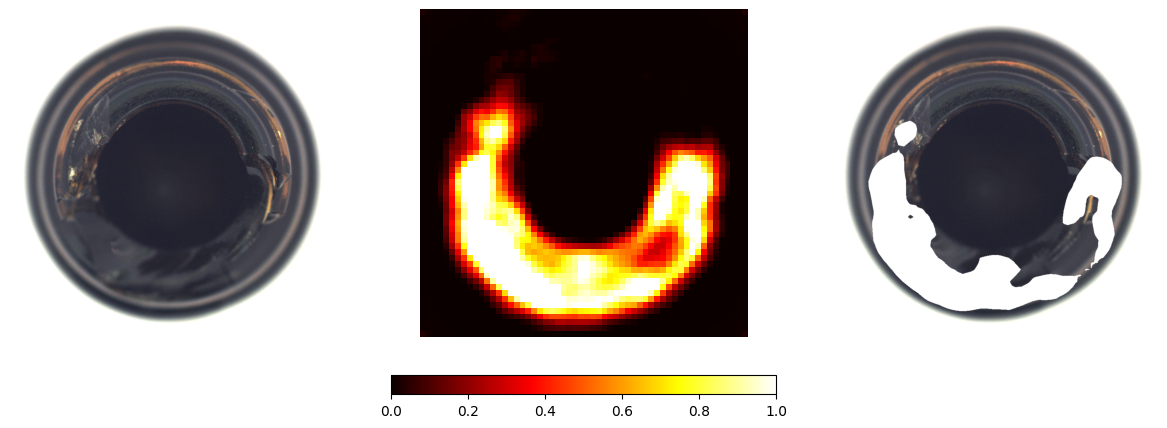

Máximo del mapa de anomalías:  tensor(1.9386, device='cuda:0')


In [23]:
# Seleccionar una imagen cualquiera del conjunto de test
test_root = Path(dataset_root) / "test"
image_files = list(test_root.rglob("*.png"))
random_image_path = random.choice(image_files)

label = random_image_path.parent.name
image_src = Image.open(random_image_path)

print("Clase:", label)

# Tamaño original de la imagen (se utilizará para reescalar el mapa final)
orig_width, orig_height = image_src.size

# Preprocesamiento utilizado por EfficientAD
# (resize, normalización y conversión a tensor)
image = ead.default_transform(image_src)

# Añadir la dimensión de batch (para obtener tamaño [1, C, H, W])
image = image[None]
image = image.to(device)

t_ini = time.perf_counter()

# Inferencia:
# - Student vs Teacher -> anomalías locales
# - Student vs Autoencoder -> anomalías globales
# - Combinación de ambas fuentes de información
map_combined, map_st, map_ae = ead.predict(
    image=image,
    teacher=teacher,
    student=student,
    autoencoder=autoencoder,
    teacher_mean=teacher_mean,
    teacher_std=teacher_std,
    q_st_start=q_st_start,
    q_st_end=q_st_end,
    q_ae_start=q_ae_start,
    q_ae_end=q_ae_end
    )

# Reescalar el mapa de anomalías al tamaño original de la imagen
map_combined_resized = torch.nn.functional.interpolate(
    map_combined,
    (image_src.height, image_src.width),
    mode='bilinear'
    )

# Convertir a numpy para visualización
map_combined_resized = map_combined_resized[0, 0].cpu().numpy()
# Umbralización simple para destacar regiones anómalas
# El umbral debe ajustarse con un estudio profundo del rendimiento del sistema
mask = map_combined_resized > 0.8
# Superponer la máscara sobre la imagen original
image_with_mask = np.array(image_src).copy()
image_with_mask[mask] = 255

t_fin = time.perf_counter()
tiempo_total = t_fin - t_ini
print(f"Tiempo de inferencia total: {tiempo_total:.3f} s")

# Visualización:
# 1) Imagen original
# 2) Mapa de anomalías
# 3) Regiones detectadas sobre la imagen
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(image_src)
axs[0].axis('off')
img2 = axs[1].imshow(map_combined[0, 0].detach().cpu().numpy(), cmap='hot', vmin=0, vmax=1)
# Añadir una única barra de color para ambas imágenes
fig.colorbar(img2, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1)
axs[1].axis('off')
axs[2].imshow(image_with_mask)
axs[2].axis('off')
plt.show()

# Reporte de la máxima puntuación de anomalía encontrada en la imagen
print(f"Máximo del mapa de anomalías: ", map_combined.max())


# 4. Evaluar rendimiento

En esta etapa analizamos el desempeño del sistema completo de detección de anomalías, conectando la salida del modelo con una evaluación cuantitativa.

El modelo no produce directamente una clase, sino un **mapa de anomalías por píxel**. A partir de este mapa se deriva un **score global por imagen**, que resume el nivel de desviación respecto del comportamiento normal aprendido durante el entrenamiento.

Con este score podemos evaluar el sistema como un detector binario (normal vs anómalo), comparando sus predicciones contra las etiquetas del conjunto de test.

El objetivo de esta sección es entonces doble:

* Medir la **capacidad de discriminación global del modelo**
* Traducir los mapas de anomalía en una **decisión operativa de detección**

En conjunto, esta evaluación permite pasar de una salida continua y espacial (mapas) a un análisis cuantitativo del rendimiento del sistema en condiciones reales de uso.


## 4.1 Obtener Scores

In [24]:
# Recorrer todas las imágenes disponibles en el conjunto de test
test_root = Path(dataset_root) / "test"

results = []

all_images = list(test_root.rglob("*.png"))
# Tomar una muestra aleatoria para acelerar la evaluación
N = min(100, len(all_images))  # por si hay menos de 100
image_subset = random.sample(all_images, N)

for image_path in tqdm(image_subset):
    # En MVTec la carpeta "good" corresponde a muestras normales
    # y el resto de las carpetas contienen defectos
    label = image_path.parent.name
    is_anomaly = label != "good"

    image_src = Image.open(image_path).convert("RGB")

    # Aplicar el mismo preprocesamiento utilizado durante el entrenamiento
    image = ead.default_transform(image_src)[None].to(device)

    # Obtener el mapa de anomalías generado por EfficientAD
    map_combined, _, _ = ead.predict(
        image=image,
        teacher=teacher,
        student=student,
        autoencoder=autoencoder,
        teacher_mean=teacher_mean,
        teacher_std=teacher_std,
        q_st_start=q_st_start,
        q_st_end=q_st_end,
        q_ae_start=q_ae_start,
        q_ae_end=q_ae_end
    )

    # Convertir el mapa local en un score global de imagen.
    # Se utiliza el máximo valor de anomalía encontrado
    score = map_combined.max().item()

    results.append({
        "file": image_path.name,
        "label": label,
        "is_anomaly": is_anomaly,
        "score": score
    })

# Consolidar los resultados en un DataFrame
df = pd.DataFrame(results)
df.head()

100%|██████████| 83/83 [00:06<00:00, 12.92it/s]


,file,label,is_anomaly,score
0,001.png,good,False,0.292302
1,005.png,good,False,0.366727
2,016.png,broken_small,True,2.627876
3,006.png,broken_small,True,2.552671
4,013.png,broken_small,True,1.442227


## 4.2. Histograma de Scores

Antes de elegir umbral sobre el mapa conviene ver la separación en las distribuciones del histograma

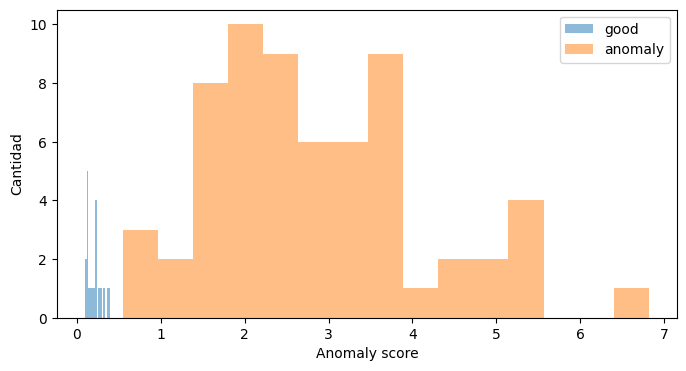

In [26]:
plt.figure(figsize=(8,4))

plt.hist(
    df[df.is_anomaly == False]["score"],
    bins=15,
    alpha=0.5,
    label="good"
)

plt.hist(
    df[df.is_anomaly == True]["score"],
    bins=15,
    alpha=0.5,
    label="anomaly"
)

plt.xlabel("Anomaly score")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

## 4.3 ROC y AUC

En esta etapa evaluamos el desempeño del sistema como clasificador binario: imagen normal (*good*) vs imagen anómala.

Aunque EfficientAD produce un mapa de anomalías a nivel píxel, para la evaluación global de una imagen necesitamos reducir ese mapa a un único valor representativo (score). En este caso, se utiliza el valor máximo del mapa, interpretándolo como la anomalía más fuerte presente en la imagen.

Con estos scores continuos no se fija todavía un umbral de decisión. En su lugar, se analiza la capacidad de separación del modelo mediante la curva ROC (Receiver Operating Characteristic), que compara:

* **TPR (True Positive Rate)**: qué proporción de anomalías se detectan correctamente
* **FPR (False Positive Rate)**: cuántas imágenes normales se clasifican como anómalas

El área bajo la curva ROC (AUC) resume esta capacidad de separación en un único valor:

* AUC = 1 → separación perfecta
* AUC = 0.5 → desempeño equivalente a azar

Finalmente, se selecciona un umbral óptimo sobre el score, buscando el mejor compromiso entre sensibilidad y especificidad. En este caso se utiliza el criterio de Youden (máxima diferencia TPR − FPR), que aproxima el mejor punto operativo del sistema.


AUC = 1.0000


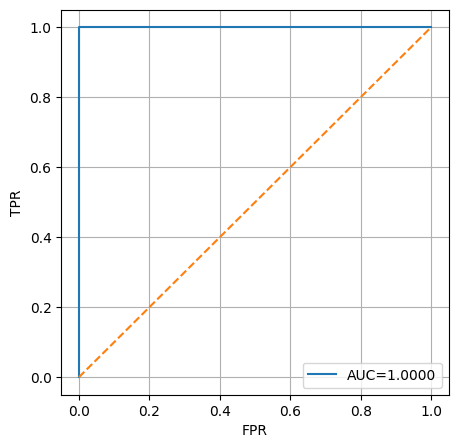

Threshold óptimo: 0.5451637506484985


In [27]:
# Etiquetas reales:
# En MVTec, "good" representa imágenes normales.
# Cualquier otra carpeta corresponde a imágenes anómalas.
y_true = df["is_anomaly"].astype(int)

# Score del modelo:
# EfficientAD no entrega directamente una clase,
# sino una puntuación continua de anomalía por imagen.
y_score = df["score"]

# Métrica global independiente de umbral:
# ROC-AUC mide qué tan bien separa el modelo normales vs anómalos
auc = roc_auc_score(y_true, y_score)

print(f"AUC = {auc:.4f}")

# Curva ROC:
# muestra el trade-off entre:
# - Tasa de falsos positivos (FPR)
# - Tasa de verdaderos positivos (TPR)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0,1],[0,1],'--')  # baseline de clasificación aleatoria
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

# Selección de umbral:
# Elegimos el punto que maximiza (TPR - FPR)
# (criterio de Youden index: mejor compromiso sensibilidad/especificidad)
best_idx = (tpr - fpr).argmax()
threshold = thresholds[best_idx]

print("Threshold óptimo:", threshold)

## 4.4 Matriz de confusión

La matriz de confusión permite evaluar el desempeño del modelo desde una perspectiva más operativa, traduciendo el score continuo de anomalía en una decisión binaria: **normal vs. anómalo**.

Para esto se utiliza un **umbral de decisión** (obtenido, por ejemplo, a partir de la curva ROC), que convierte el score en una clase predicha.

## ¿Qué estamos comparando?

* **Etiqueta real**: si la imagen es `good` (normal) o defectuosa (anómala)
* **Predicción del modelo**: resultado de aplicar el umbral al score de anomalía

## Estructura de la matriz

La matriz de confusión resume cuatro casos:

* **Verdaderos positivos (TP)**: anomalías correctamente detectadas
* **Verdaderos negativos (TN)**: imágenes normales correctamente clasificadas
* **Falsos positivos (FP)**: normales detectadas como anomalías
* **Falsos negativos (FN)**: anomalías no detectadas

## Utilidad de la matriz y de las métricas que se derivan

A diferencia del AUC, que es una métrica global independiente del umbral, la matriz de confusión muestra el comportamiento **en condiciones de operación reales**.

Permite analizar cosas como:

* cuántos defectos se escapan (FN)
* cuántas falsas alarmas se generan (FP)
* equilibrio entre seguridad y sobre-detección

En sistemas de inspección industrial, este balance suele ser más importante que una métrica agregada.


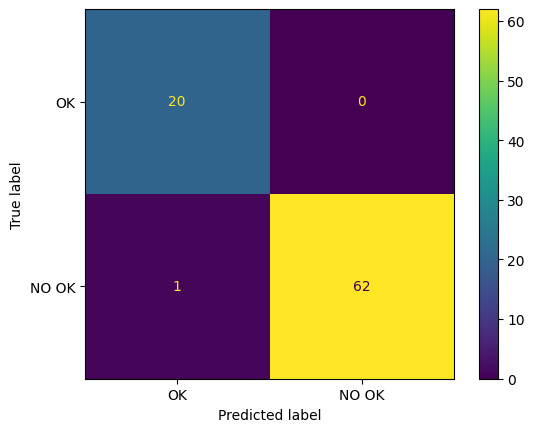

In [28]:
y_pred = y_score > threshold

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["OK", "NO OK"]
)
disp.plot()
plt.show()

## 4.5. Métricas de evaluación

In [29]:
print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
print(f"Precision: {precision_score(y_true,y_pred):.4f}")
print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
print(f"F1       : {f1_score(y_true,y_pred):.4f}")

Accuracy : 0.9880
Precision: 1.0000
Recall   : 0.9841
F1       : 0.9920
